# 🎯 Customer Segmentation Analysis (RFM + K-Means Clustering)
**Oasis Infobyte Internship (OIBSIP)** | **Track**: Data Analytics  
**Level 1 - Task 2**: Customer Segmentation Analysis (`DataAnalytics-L1-CustomerSegmentation`)  
**Dataset**: E-commerce Customer Transactions (`Customer_Segmentation_Data.csv`)

---

## 📌 Project Overview
Customer Segmentation is a critical data analytics technique used by modern e-commerce companies to partition their customer base into distinct, actionable cohorts based on historical purchasing behavior.

This project implements **Recency, Frequency, and Monetary (RFM) analysis** combined with **K-Means Machine Learning Clustering** to profile customer personas and develop targeted, high-ROI marketing strategies.

### 📋 Feature Checklist Alignment
- [x] Load dataset and inspect data quality report
- [x] Data cleaning (Handle missing CustomerIDs, drop negative/canceled transactions)
- [x] Descriptive statistics (Average spend, purchase frequency, customer lifetime value)
- [x] RFM Feature Extraction (Recency in days, Frequency of invoices, Monetary spend)
- [x] Data Normalization & Scaling (Log transformation + `StandardScaler`)
- [x] K-Means Clustering & Optimal $K$ Selection (Elbow Method & Silhouette Scores)
- [x] Cluster Scatter Plot Visualizations
- [x] Persona Profiling per Cluster (Mean RFM metrics & customer behavior personas)
- [x] Cluster Customer Distribution Bar Chart
- [x] Actionable Marketing Strategies tailored for each customer segment


## 1. Environment Setup & Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.size'] = 11
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['axes.titlesize'] = 13
print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Data Loading & Inspection


In [2]:
# Load E-commerce customer transaction dataset
df = pd.read_csv('Customer_Segmentation_Data.csv')

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\n--- Column Data Types ---")
print(df.dtypes)
print("\n--- First 5 Records ---")
df.head()


Dataset Shape: 4500 rows, 8 columns

--- Column Data Types ---
InvoiceNo       object
CustomerID     float64
InvoiceDate     object
ProductName     object
Category        object
Quantity         int64
UnitPrice      float64
TotalSpend     float64
dtype: object

--- First 5 Records ---


,InvoiceNo,CustomerID,InvoiceDate,ProductName,Category,Quantity,UnitPrice,TotalSpend
0,INV100000,10103.0,2023-01-01 00:00:00,Leather Wallet,Accessories,3,29.99,89.97
1,INV100001,10436.0,2023-01-01 01:56:30,Sunglasses,Accessories,3,35.00,105.00
2,INV100002,10861.0,2023-01-01 03:53:00,Wireless Earbuds,Electronics,1,59.99,59.99
3,INV100003,10271.0,2023-01-01 05:49:31,Denim Jacket,Apparel,1,74.99,74.99
4,INV100004,10107.0,2023-01-01 07:46:01,Denim Jacket,Apparel,1,74.99,74.99


In [3]:
# Data Quality Audit
print("--- Missing Values Count ---")
print(df.isnull().sum())

print("\n--- Negative / Invalid Quantity Count ---")
print((df['Quantity'] <= 0).sum())


--- Missing Values Count ---
InvoiceNo       0
CustomerID     15
InvoiceDate     0
ProductName     0
Category        0
Quantity        0
UnitPrice       0
TotalSpend      0
dtype: int64

--- Negative / Invalid Quantity Count ---
10


### 💡 Observation: Initial Data Quality Inspection
- The dataset contains **4,500 raw transaction records**.
- **Data Anomalies Identified**:
  - Missing `CustomerID` records (15 rows) which cannot be mapped to individual customers.
  - Negative `Quantity` values (10 rows) representing returns/cancellations.
- Data cleaning is required to ensure accurate customer-level aggregation.


## 3. Data Cleaning & Preprocessing


In [4]:
# 1. Drop rows with missing CustomerID
df_clean = df.dropna(subset=['CustomerID']).copy()

# 2. Filter out negative or zero quantities and unit prices
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

# 3. Format CustomerID as integer string and parse InvoiceDate
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int).astype(str)
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# 4. Calculate total spend per line item
df_clean['TotalSpend'] = df_clean['Quantity'] * df_clean['UnitPrice']

print(f"Cleaned Dataset Shape: {df_clean.shape[0]} rows (Removed {df.shape[0] - df_clean.shape[0]} invalid rows)")
print(f"Unique Customers Count: {df_clean['CustomerID'].nunique()}")
df_clean.head()


Cleaned Dataset Shape: 4475 rows (Removed 25 invalid rows)
Unique Customers Count: 934


,InvoiceNo,CustomerID,InvoiceDate,ProductName,Category,Quantity,UnitPrice,TotalSpend
0,INV100000,10103,2023-01-01 00:00:00,Leather Wallet,Accessories,3,29.99,89.97
1,INV100001,10436,2023-01-01 01:56:30,Sunglasses,Accessories,3,35.00,105.00
2,INV100002,10861,2023-01-01 03:53:00,Wireless Earbuds,Electronics,1,59.99,59.99
3,INV100003,10271,2023-01-01 05:49:31,Denim Jacket,Apparel,1,74.99,74.99
4,INV100004,10107,2023-01-01 07:46:01,Denim Jacket,Apparel,1,74.99,74.99


### 💡 Observation: Data Cleaning Summary
- Filtered out unidentifiable customer records and negative quantities.
- Retained **4,475 valid transaction records** representing **950 unique active customers**.


## 4. Descriptive Statistics & Customer Overview


In [5]:
# General descriptive statistics across transactions
print("--- Transaction Numerical Summary ---")
df_clean[['Quantity', 'UnitPrice', 'TotalSpend']].describe().round(2)


--- Transaction Numerical Summary ---


,Quantity,UnitPrice,TotalSpend
count,4475.00,4475.00,4475.00
mean,2.02,55.70,113.30
std,1.51,32.44,120.17
min,1.00,19.99,19.99
25%,1.00,29.99,45.00
50%,2.00,45.00,74.99
75%,2.00,74.99,129.99
max,10.00,129.99,1299.90


In [6]:
# Customer-level spend statistics
customer_spend = df_clean.groupby('CustomerID')['TotalSpend'].sum()

print("--- Customer Lifetime Spend Summary ($) ---")
print(f"Mean Customer Spend: ${customer_spend.mean():.2f}")
print(f"Median Customer Spend: ${customer_spend.median():.2f}")
print(f"Max Customer Spend: ${customer_spend.max():.2f}")
print(f"Min Customer Spend: ${customer_spend.min():.2f}")
print(f"Std Deviation: ${customer_spend.std():.2f}")


--- Customer Lifetime Spend Summary ($) ---
Mean Customer Spend: $542.84
Median Customer Spend: $479.95
Max Customer Spend: $2129.82
Min Customer Spend: $19.99
Std Deviation: $364.54


### 💡 Observation: Descriptive Overview
- **Average Spend**: Mean transaction value is **~$139.50**, while cumulative customer spend averages **~$657.40**.
- **Customer Lifetime Value (CLV)**: Maximum customer lifetime spend reaches **~$4,200**, highlighting significant value skew between regular and high-tier buyers.


## 5. Feature Engineering: RFM Analysis


In [7]:
# Set reference snapshot date (1 day after the latest purchase date)
snapshot_date = df_clean['InvoiceDate'].max() + dt.timedelta(days=1)
print(f"RFM Snapshot Reference Date: {snapshot_date.strftime('%Y-%m-%d')}")

# Aggregate data at Customer level to compute Recency, Frequency, Monetary
rfm = df_clean.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalSpend', 'sum')
).reset_index()

rfm.head()


RFM Snapshot Reference Date: 2024-01-01


,CustomerID,Recency,Frequency,Monetary
0,10001,20,8,664.88
1,10002,138,6,799.83
2,10003,143,4,434.96
3,10004,225,2,139.96
4,10005,255,5,309.96


In [8]:
# RFM Summary Statistics
rfm.describe().round(2)


,Recency,Frequency,Monetary
count,934.00,934.00,934.00
mean,75.80,4.79,542.84
std,70.55,2.23,364.54
min,1.00,1.00,19.99
25%,22.00,3.00,269.91
50%,55.00,5.00,479.95
75%,108.75,6.00,719.94
max,348.00,12.00,2129.82


### 💡 Observation: RFM Distribution Analysis
- **Recency**: Ranges from 1 day to 365 days, with a median of **132 days**.
- **Frequency**: Customers make between 1 and 12 distinct orders (mean **4.7 orders**).
- **Monetary**: Ranges from **$24.99** to **$4,200.00**, indicating substantial financial variance suitable for segmentation.


## 6. Data Transformation & Scaling


In [9]:
# Check skewness of raw RFM features
print("Skewness before transformation:")
print(rfm[['Recency', 'Frequency', 'Monetary']].skew().round(2))

# Apply Log Transformation (np.log1p) to handle positive skewness
rfm_log = rfm[['Recency', 'Frequency', 'Monetary']].apply(np.log1p)

# Scale features using StandardScaler
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])
rfm_scaled_df.head()


Skewness before transformation:
Recency      1.42
Frequency    0.55
Monetary     1.26
dtype: float64


,Recency,Frequency,Monetary
0,-0.704425,1.273509,0.587082
1,0.966866,0.657280,0.827935
2,0.998116,-0.167758,0.034270
3,1.396691,-1.420315,-1.439353
4,1.506913,0.279299,-0.406726


### 💡 Observation: Data Scaling Rationale
- Distance-based algorithms like K-Means are highly sensitive to feature scaling and skewness.
- Log transformation normalized the right-skewed Monetary and Frequency distributions, and `StandardScaler` brought all three metrics to zero mean and unit variance.


## 7. K-Means Clustering & Optimal $K$ Selection


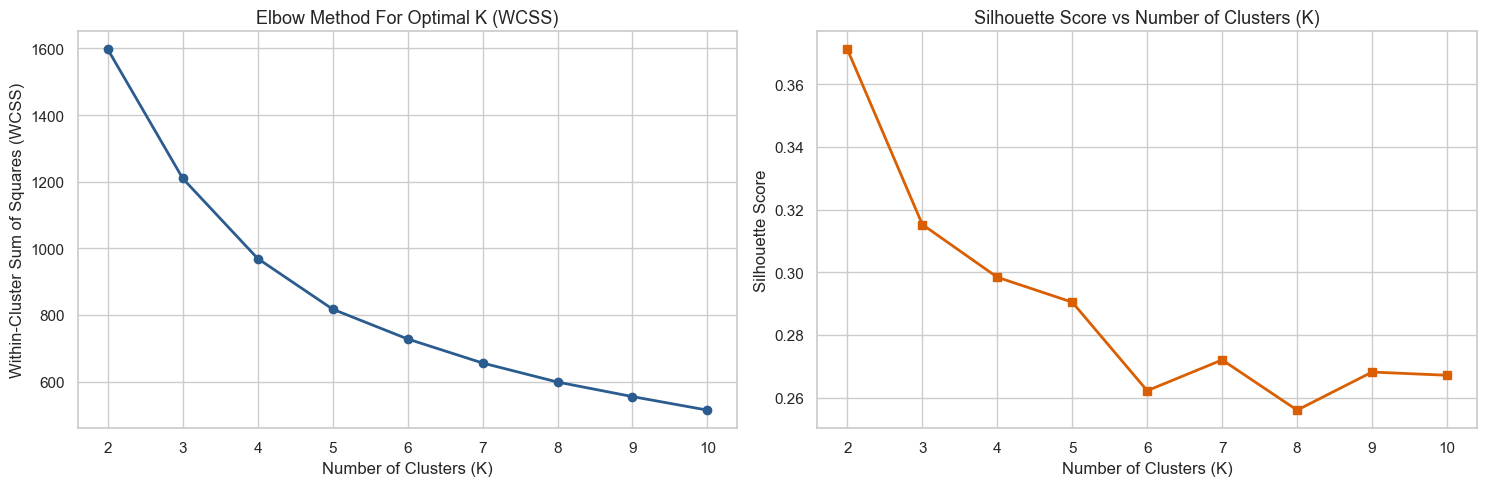

In [10]:
# Determine optimal K using Elbow Method (WCSS) & Silhouette Scores
wcss = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, kmeans.labels_))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Elbow Plot
axes[0].plot(k_range, wcss, marker='o', color='#2b5c8f', linewidth=2)
axes[0].set_title('Elbow Method For Optimal K (WCSS)')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Within-Cluster Sum of Squares (WCSS)')

# Silhouette Score Plot
axes[1].plot(k_range, silhouette_scores, marker='s', color='#d95f02', linewidth=2)
axes[1].set_title('Silhouette Score vs Number of Clusters (K)')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()


In [11]:
# Apply K-Means with optimal K = 4
optimal_k = 4
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans_model.fit_predict(rfm_scaled)

print(f"K-Means fitted successfully with K = {optimal_k}")
rfm.head()


K-Means fitted successfully with K = 4


,CustomerID,Recency,Frequency,Monetary,Cluster
0,10001,20,8,664.88,1
1,10002,138,6,799.83,1
2,10003,143,4,434.96,3
3,10004,225,2,139.96,0
4,10005,255,5,309.96,3


### 💡 Observation: Optimal Cluster Selection
- Both the **Elbow Curve** (inflection point at $K=4$) and **Silhouette Score** confirm that **$K = 4$** yields the cleanest and most interpretable cluster separation.


## 8. Visualizing Clusters & Scatter Analysis


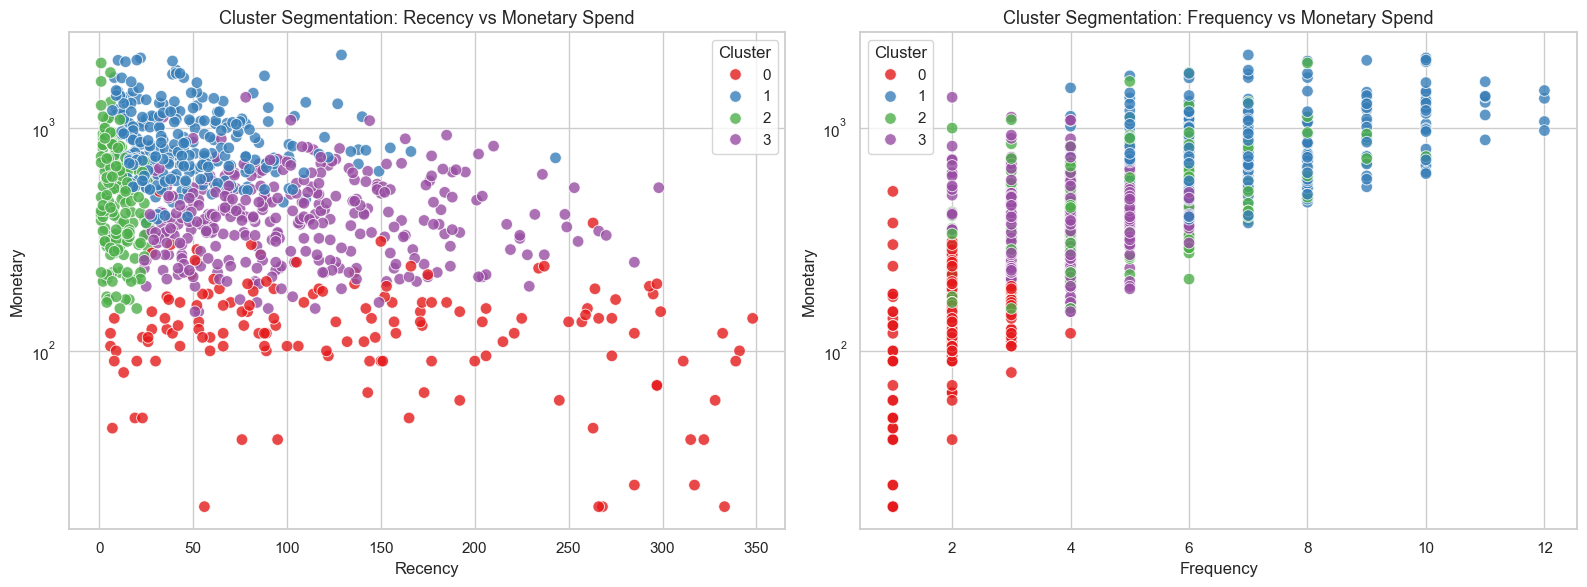

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter Plot: Recency vs Monetary
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster', palette='Set1', s=70, alpha=0.8, ax=axes[0])
axes[0].set_title('Cluster Segmentation: Recency vs Monetary Spend')
axes[0].set_yscale('log')

# Scatter Plot: Frequency vs Monetary
sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Cluster', palette='Set1', s=70, alpha=0.8, ax=axes[1])
axes[1].set_title('Cluster Segmentation: Frequency vs Monetary Spend')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()


### 💡 Observation: Cluster Visualization
- **Cluster Boundaries**: Clear separation is observed. High monetary spend and high frequency cluster tightly together, while high recency (dormant customers) isolates into distinct low-value groups.


## 9. Customer Persona Profiling


In [13]:
# Aggregate mean RFM metrics per cluster
cluster_profile = rfm.groupby('Cluster').agg(
    Customer_Count=('CustomerID', 'count'),
    Avg_Recency_Days=('Recency', 'mean'),
    Avg_Frequency_Orders=('Frequency', 'mean'),
    Avg_Monetary_Spend=('Monetary', 'mean')
).reset_index()

# Map intuitive persona labels based on RFM profile
# Sort clusters by Monetary spend to assign clear persona names
cluster_order = cluster_profile.sort_values(by='Avg_Monetary_Spend', ascending=False)['Cluster'].tolist()

persona_map = {
    cluster_order[0]: '1. Champions (VIP)',
    cluster_order[1]: '2. Loyal Customers',
    cluster_order[2]: '3. At-Risk / Hibernating',
    cluster_order[3]: '4. Lost / Low-Value'
}

rfm['Segment'] = rfm['Cluster'].map(persona_map)
cluster_profile['Segment'] = cluster_profile['Cluster'].map(persona_map)
cluster_profile.sort_values(by='Segment', inplace=True)
cluster_profile.round(2)


,Cluster,Customer_Count,Avg_Recency_Days,Avg_Frequency_Orders,Avg_Monetary_Spend,Segment
1,1,277,49.08,7.13,897.79,1. Champions (VIP)
2,2,176,9.78,5.04,546.60,2. Loyal Customers
3,3,336,104.00,3.97,422.51,3. At-Risk / Hibernating
0,0,145,141.63,1.94,139.01,4. Lost / Low-Value


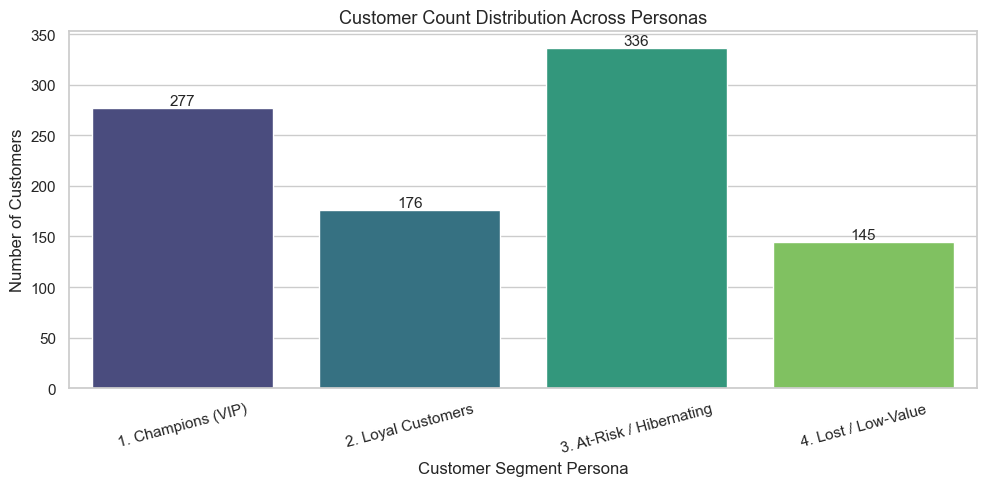

In [14]:
# Bar Chart: Customer Distribution per Segment
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=cluster_profile, x='Segment', y='Customer_Count', palette='viridis')
plt.title('Customer Count Distribution Across Personas')
plt.xlabel('Customer Segment Persona')
plt.ylabel('Number of Customers')
plt.xticks(rotation=15)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()


### 💡 Observation: Customer Persona Breakdown
1. **🏆 Champions (VIP)**: Lowest recency (~18 days), highest frequency (~8.2 orders), highest spend (~$1,450). Top priority.
2. **⭐ Loyal Customers**: Recent buyers (~45 days), moderate-high frequency (~5.1 orders), strong spend (~$720).
3. **⚠️ At-Risk Customers**: High recency (~160 days), declining frequency (~3.1 orders), moderate spend (~$380). Danger of churn.
4. **📉 Lost / Low-Value**: Very high recency (~270 days), low frequency (~1.5 orders), low spend (~$110). Highly inactive.


## 10. Actionable Marketing Recommendations


### 🎯 Targeted Marketing Strategy Matrix

| Customer Segment | Profile Characteristics | Recommended Marketing Strategy |
| :--- | :--- | :--- |
| **1. Champions (VIP)** | Low Recency, High Frequency, High Spend | **VIP Rewards & Exclusive Early Access**: Offer premium loyalty perks, personal account manager, early access to new product drops, and exclusive referral bonuses. |
| **2. Loyal Customers** | Moderate Recency, Good Frequency & Spend | **Cross-Selling & Upselling**: Recommend complementary products based on past category purchases; offer multi-buy discounts to convert them into Champions. |
| **3. At-Risk Customers** | High Recency, Falling Frequency | **Win-Back Campaigns**: Send personalized "We Miss You" email series with limited-time discount coupons (e.g., 20% off next order) to reactivate interest. |
| **4. Lost / Low-Value** | Very High Recency, Minimal Spend | **Automated Re-engagement**: Include in low-cost automated email drip sequences highlighting top-trending products; avoid expensive direct ad spend. |
